In [1]:
%load_ext autoreload
%autoreload 2
import os
import pandas as pd
import matplotlib.pyplot as plt

# IEEE Double-Column Formatting Standard
plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 300
})

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

from src.config import SimConfig, EnvConfig
from src.utils.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker, print_markdown_table
from src.solvers import AugmentedHybridSDPSolver
from src.plants import AugmentedHybridPlant
from src.controllers import build_approach, AugmentedValueControl

In [2]:
env = EnvConfig()
fleet_data = load_and_cache_entire_fleet(env)
exclude_days = [1, 2, 3]

OPTIMAL_DP = 50.0
OPTIMAL_DT = 300
N_PD = 5

Loading fleet data from binary cache (fleet_data_cache_scale_0.75.npz)...
 -> Cache instantly loaded in 0.133 seconds.


In [3]:
# The complete set of divisors for 12 FC modules
pack_test_values = [1, 2, 3, 4, 6, 12]
results_data = []

print("--- RUNNING ACTUATOR CONDENSATION SENSITIVITY ---")

for pack in pack_test_values:
    print(f"\n[ Evaluating Module Pack Size: n_pack = {pack} ]")
    
    config = SimConfig(
        dP=OPTIMAL_DP,
        Dt=OPTIMAL_DT,
        N_Pd=N_PD,
        n_pack=pack,
    )
    
    benchmarker = VoyageBenchmarker(fleet_data, env, config, exclude_days)
    
    value_factory = build_approach(
        controller_cls=AugmentedValueControl,
        plant_cls=AugmentedHybridPlant,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    )
    
    report = benchmarker.run_leave_one_out(value_factory)
    avg_metrics = report.summary.loc['Average']
    
    results_data.append({
        'n_pack': pack,
        'Total Cost [$]': avg_metrics['Total Cost [$]'],
        'Operating Cost [$]': avg_metrics['Operating Cost [$]'],
        'Switching Cost [$]': avg_metrics['Switching Cost [$]'],
        'Battery Cost [$]': avg_metrics['Battery Cost [$]'],
        'Offline Compute Time [s]': avg_metrics['Offline Compute Time [s]']
    })

df_pack = pd.DataFrame(results_data).set_index('n_pack')

--- RUNNING ACTUATOR CONDENSATION SENSITIVITY ---

[ Evaluating Module Pack Size: n_pack = 1 ]

⚙️  EMS Configuration Loaded | Smart Grid: ON
 -> dP Step Size       : 50.0 kW
 -> Grid Dimensions    : N_d=5, N_n=13, N_soc=73, N_fc=49, N_bat=41
 -> Augmented Space |S|: 232,505 states
 -> Action Space |A|   : 533 actions
 -> Time steps   : (288,) steps/day
 -> Est. Big-O Comput. : O(36,025,254,720) operations / day
 -> Est. RAM Footprint : ~1281.62 MB

 [Vault] Cache HIT: Markov Chain succesfully loaded for days [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache HIT: SDP solution succesfully loaded (AugmentedHybridSDPSolver)
 [Vault] Cache HIT: Markov Chain succesfully loaded for days [4, 6, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache HIT: SDP solution succesfully loaded (AugmentedHybridSDPSolver)
 [Vault] Cache HIT: Markov Chain succesfully loaded for days [4, 5, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache HIT: SDP solution succesfully loaded (AugmentedHybridSDPSolver)
 [Vault] Cache HIT

In [4]:
print("\n--- ACTUATOR CONDENSATION SUMMARY ---")
print_markdown_table(df_pack)


--- ACTUATOR CONDENSATION SUMMARY ---
| n_pack | Total Cost [$] | Operating Cost [$] | Switching Cost [$] | Battery Cost [$] | Offline Compute Time [s] |
|--------|----------------|--------------------|--------------------|------------------|--------------------------|
| 1      | 4033.15        | 3763.23            | 116.81             | 31.59            | 463.85                   |
| 2      | 4053.66        | 3763.58            | 125.60             | 31.51            | 162.29                   |
| 3      | 4061.70        | 3761.78            | 112.90             | 32.07            | 70.82                    |
| 4      | 4060.50        | 3800.62            | 86.02              | 31.27            | 35.06                    |
| 6      | 4313.10        | 3787.10            | 195.00             | 35.53            | 26.53                    |
| 12     | 4429.90        | 4158.73            | 32.26              | 31.68            | 6.41                     |


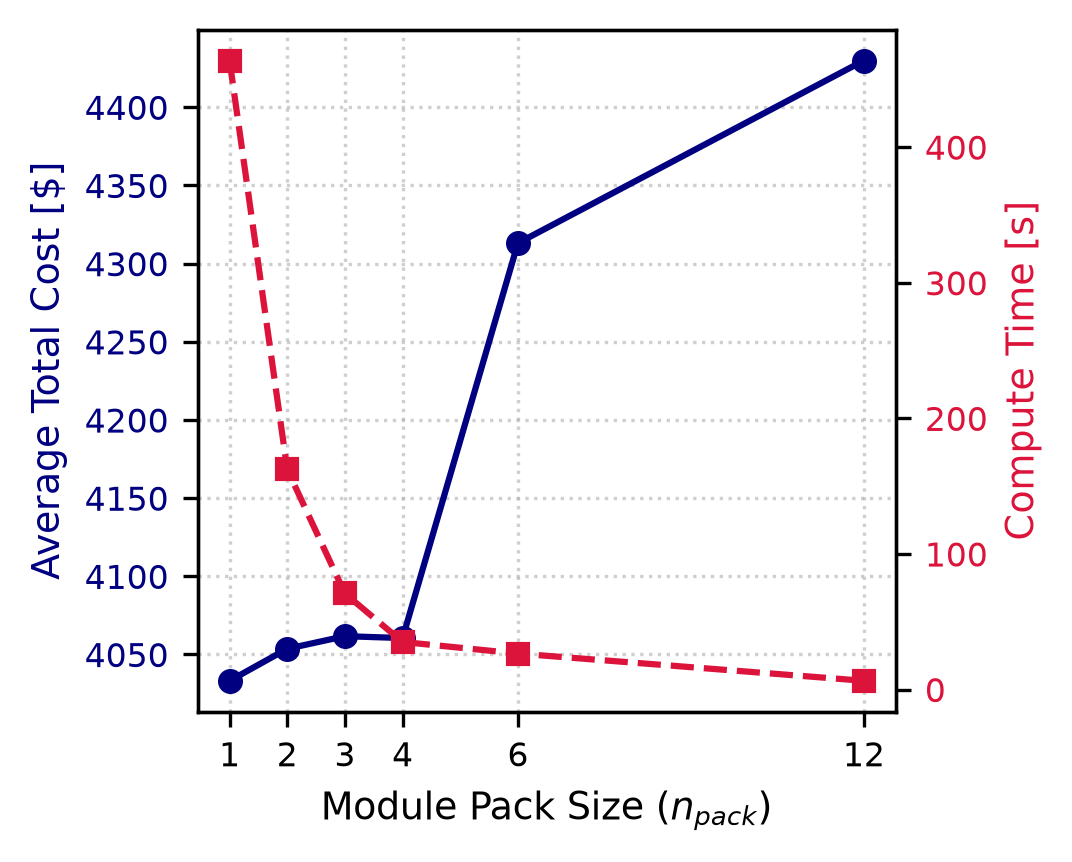

In [5]:
# Plotting the Twin-Axis L-Curve (Formatted for 3.5-inch column)
fig, ax1 = plt.subplots(figsize=(3.5, 2.8))

times = df_pack['Offline Compute Time [s]'].values
costs = df_pack['Total Cost [$]'].values
packs = df_pack.index.values

# Left Axis: Cost (Navy)
color1 = 'navy'
ax1.plot(packs, costs, marker='o', linestyle='-', color=color1, linewidth=1.5, markersize=5)
ax1.set_xlabel('Module Pack Size ($n_{pack}$)')
ax1.set_ylabel('Average Total Cost [$]', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(packs)
ax1.grid(True, linestyle=':', alpha=0.6)

# Right Axis: Compute Time (Crimson, dashed)
ax2 = ax1.twinx()
color2 = 'crimson'
ax2.plot(packs, times, marker='s', linestyle='--', color=color2, linewidth=1.5, markersize=5)
ax2.set_ylabel('Compute Time [s]', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.tight_layout(pad=0.5)
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/02_actuator_condensation.png')
plt.show()